# Day 10 — Pop Culture
### #30DayChartChallenge | April 2026

**The Golden Age of TV: Ratings Distribution.** A visualization displaying the distribution of TVMaze viewer ratings for every episode of five iconic pop-culture television shows. This chart uses a combination of violin density curves, boxplots, and jittered raw points to showcase how viewer reception spread over each show's run.

*Breaking Bad* demonstrates incredibly consistent and steadily ascending ratings. *The Simpsons* highlights a massive spread across its 800+ episodes. *Game of Thrones* shows a harsh "cliff-dive" long-tail stretching toward the 5.0 range due to its polarizing final season.

**Data:** TVMaze API (Public Viewer Ratings)  
**Author:** Sharfudeen Yasar Arafath

In [1]:
# — packages ------------------------------------------------------------------

library(ggplot2)
library(dplyr)
library(showtext)
library(sysfonts)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Loading required package: sysfonts

Loading required package: showtextdb



In [2]:
# — fonts & display size ------------------------------------------------------

font_add_google("Outfit", "outfit")
font_add_google("Roboto Condensed", "roboto_condensed")
font_add_google("JetBrains Mono", "jetbrains")
showtext_auto()
showtext_opts(dpi = 300)

options(repr.plot.width = 12, repr.plot.height = 9, repr.plot.res = 300)

In [3]:
# — read data -----------------------------------------------------------------

df <- read.csv("../../data/day_10/tv_show_ratings.csv", stringsAsFactors = FALSE)

# Order shows by median rating for a clean cascading visual
df <- df %>%
  mutate(show = factor(show, levels = c("Breaking Bad", "Succession", "The Office", "Game of Thrones", "The Simpsons")))

str(df)
cat("Total Episodes:", nrow(df), "\n")

'data.frame':	1177 obs. of  5 variables:
 $ show   : Factor w/ 5 levels "Breaking Bad",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ season : int  1 1 1 1 1 1 1 2 2 2 ...
 $ episode: int  1 2 3 4 5 6 7 1 2 3 ...
 $ name   : chr  "Pilot" "Cat's in the Bag..." "...and the Bag's in the River" "Cancer Man" ...
 $ rating : num  8.2 7.9 8.1 7.5 7.7 8.8 8 7.9 8.3 7.9 ...
Total Episodes: 1177 


In [4]:
# — theme & palette -----------------------------------------------------------

bg       <- "#0a0e17"
txt      <- "#E6EDF3"
txt_dim  <- "#8B949E"
txt_cap  <- "#484F58"
grid_col <- "#1a2030"

show_colors <- c(
  "Breaking Bad"    = "#34D399", # Emerald Green
  "Succession"      = "#60A5FA", # Blue
  "The Office"      = "#FBBF24", # Amber Yellow
  "Game of Thrones" = "#A78BFA", # Purple
  "The Simpsons"    = "#F472B6"  # Pink
)

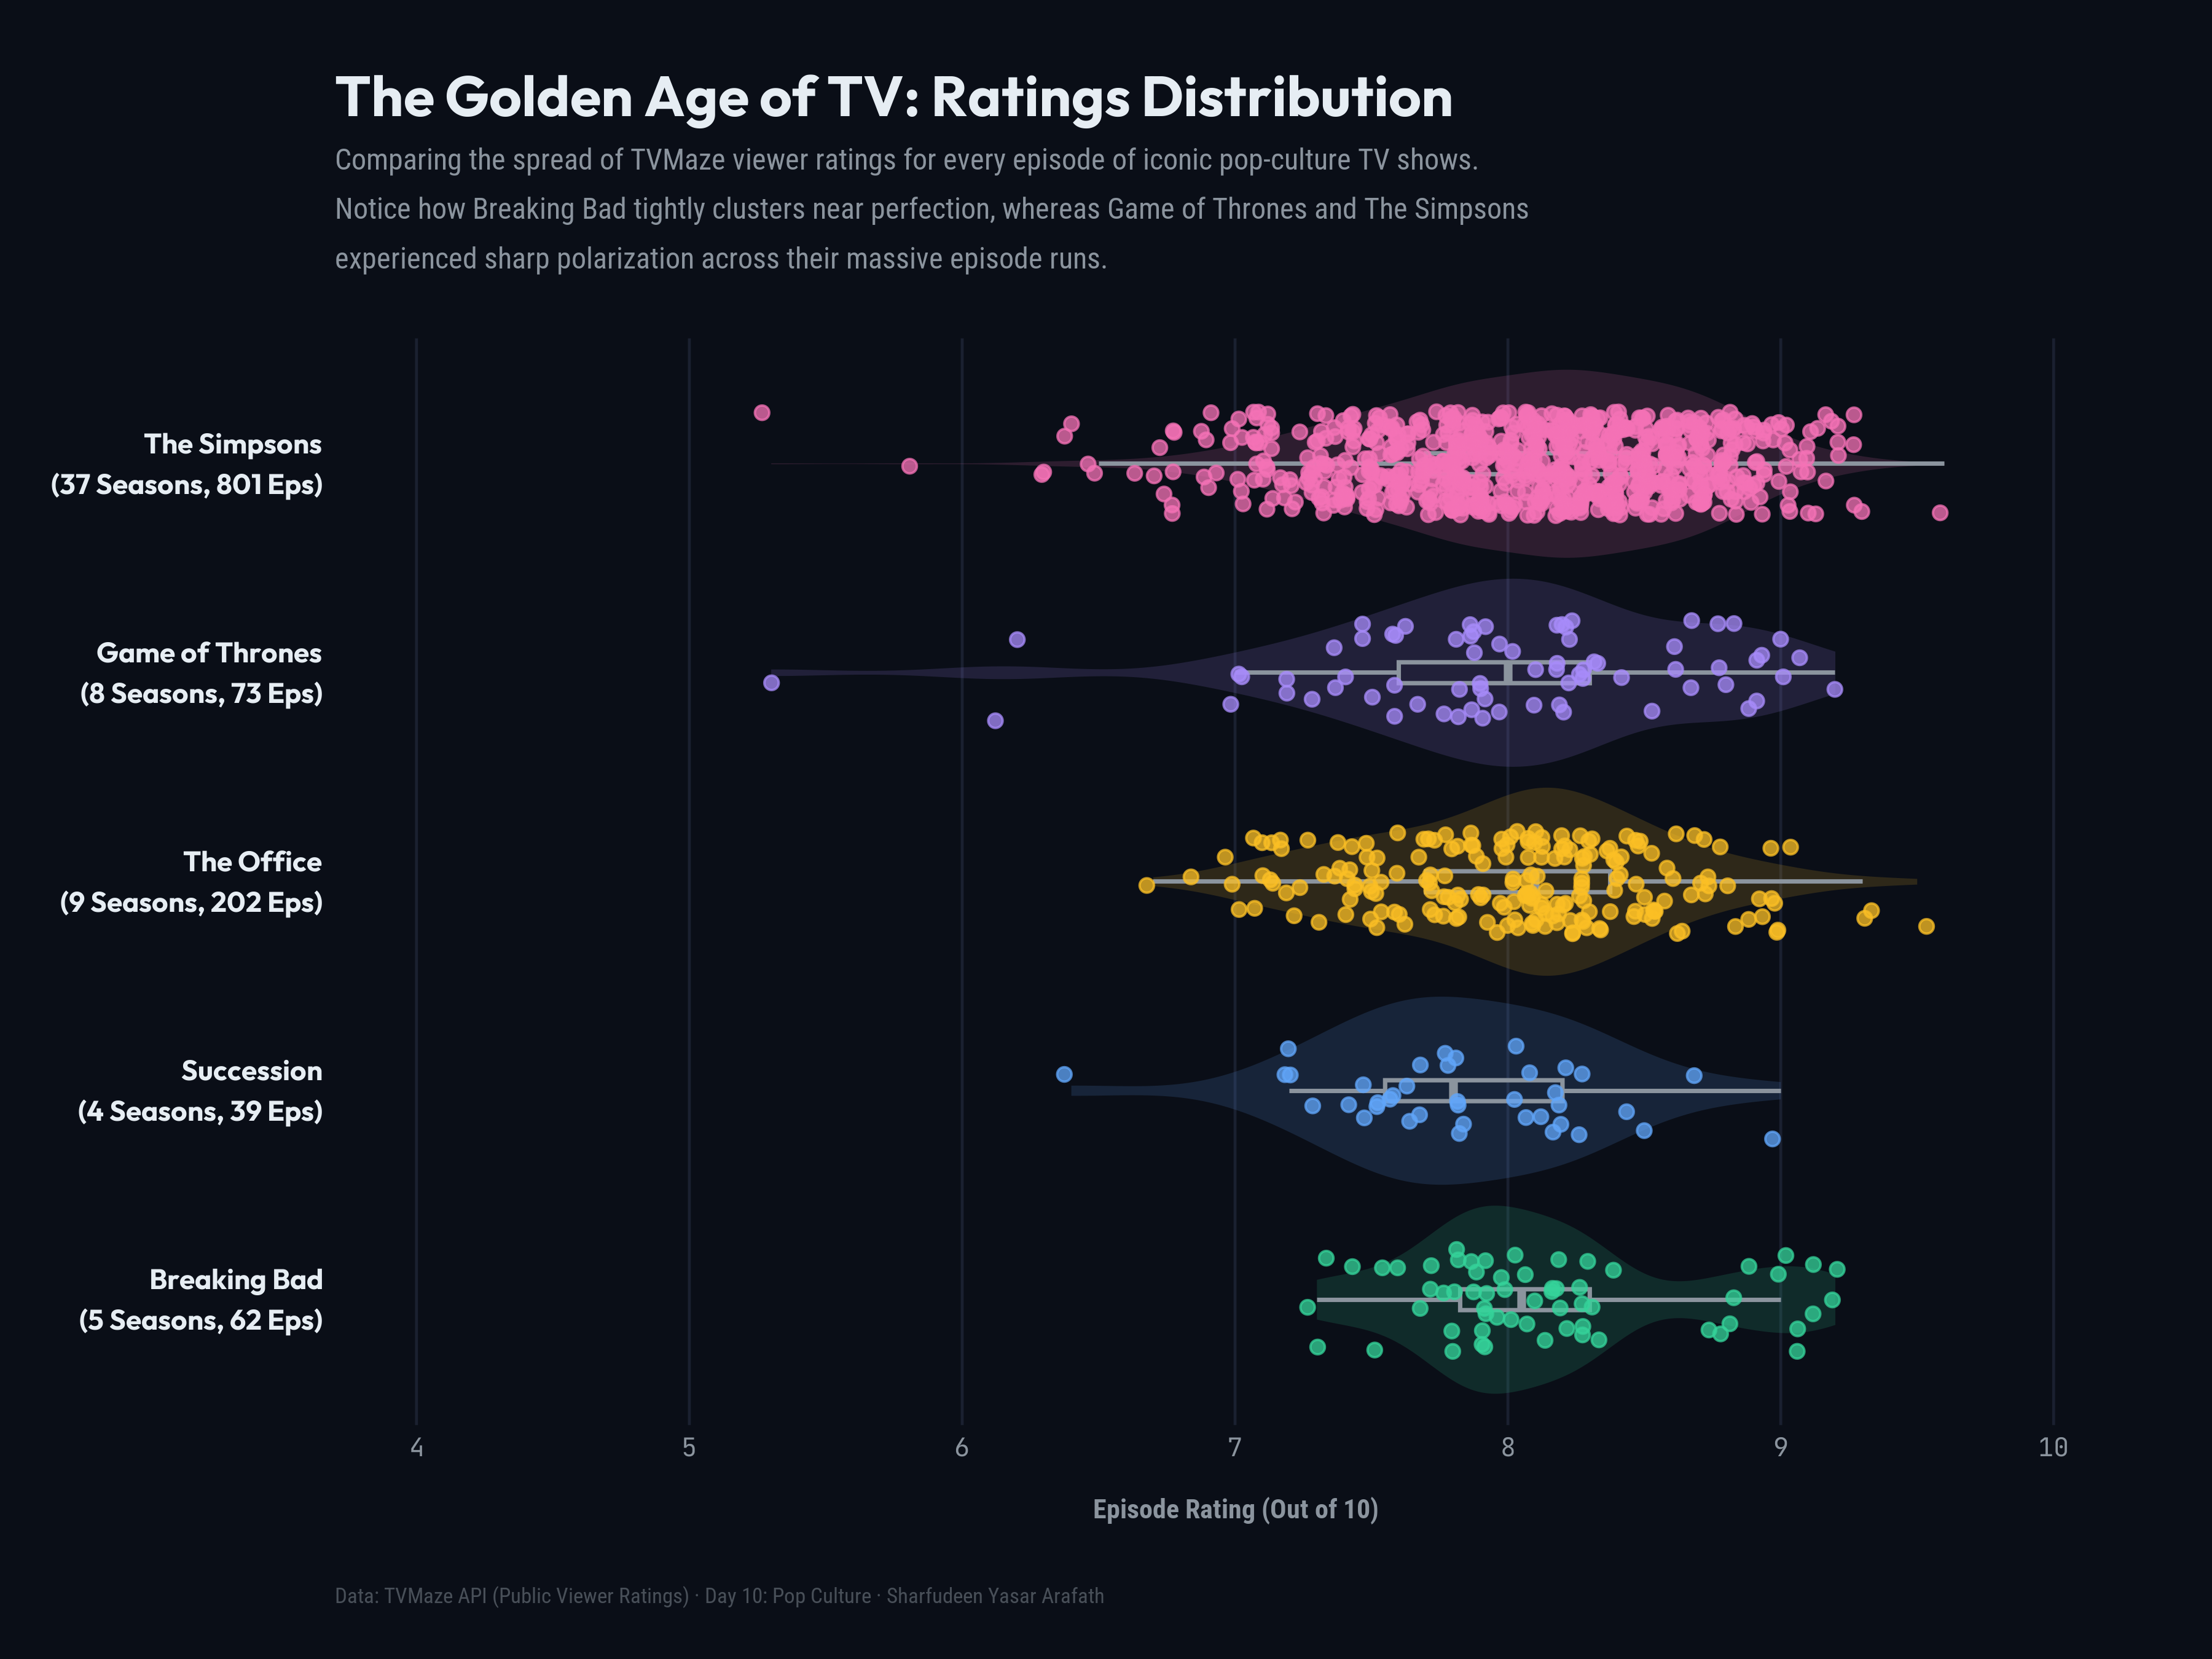

In [5]:
# — build the plot ------------------------------------------------------------

# Create custom labels showing seasons and episodes
custom_labels <- df %>%
  group_by(show) %>%
  summarize(
    label = sprintf("%s\n(%d Seasons, %d Eps)", unique(show), max(season), n()),
    .groups = "drop"
  ) %>%
  pull(label, name = show)

p <- ggplot(df, aes(x = rating, y = show, fill = show, color = show)) +
  
  # Background Violin Density
  geom_violin(alpha = 0.15, color = NA, scale = "width", adjust = 1.2) + 
  
  # Structural Boxplot
  geom_boxplot(width = 0.1, fill = "transparent", color = txt_dim, outlier.shape = NA, linewidth = 0.6) +
  
  # Raw Jittered Data Points
  geom_jitter(height = 0.25, size = 2.2, alpha = 0.75) +
  
  # Scales
  scale_x_continuous(breaks = seq(4, 10, 1), limits = c(4, 10)) +
  scale_y_discrete(labels = custom_labels) +
  scale_color_manual(values = show_colors) +
  scale_fill_manual(values = show_colors) +
  
  # Labelling
  labs(
    title = "The Golden Age of TV: Ratings Distribution",
    subtitle = paste0(
      "Comparing the spread of TVMaze viewer ratings for every episode of iconic pop-culture TV shows.\n",
      "Notice how Breaking Bad tightly clusters near perfection, whereas Game of Thrones and The Simpsons\n",
      "experienced sharp polarization across their massive episode runs."
    ),
    x = "Episode Rating (Out of 10)",
    y = NULL,
    caption = "Data: TVMaze API (Public Viewer Ratings) \u00b7 Day 10: Pop Culture \u00b7 Sharfudeen Yasar Arafath"
  ) +
  
  # Theming
  theme_minimal(base_family = "roboto_condensed") +
  theme(
    plot.title = element_text(family = "outfit", face = "bold", size = 22, color = txt, margin = margin(t = 10, b = 8)),
    plot.subtitle = element_text(size = 11.5, color = txt_dim, lineheight = 1.4, margin = margin(b = 25)),
    plot.caption = element_text(size = 8.5, color = txt_cap, margin = margin(t = 25), hjust = 0),
    
    axis.text.y = element_text(family = "outfit", face = "bold", size = 11, color = txt, margin = margin(r = 10), lineheight = 1.2),
    axis.text.x = element_text(family = "jetbrains", size = 10, color = txt_dim),
    axis.title.x = element_text(size = 10.5, face = "bold", color = txt_dim, margin = margin(t = 15)),
    
    legend.position = "none",
    
    panel.grid.major.x = element_line(color = grid_col, linewidth = 0.4),
    panel.grid.minor.x = element_blank(),
    panel.grid.major.y = element_blank(),
    
    plot.background = element_rect(fill = bg, color = NA),
    panel.background = element_rect(fill = bg, color = NA),
    plot.margin = margin(20, 30, 20, 20)
  )

p

In [6]:
# — save ----------------------------------------------------------------------

ggsave("../../chart/day_10_pop_culture.png",
       plot = p, width = 12, height = 9, dpi = 300, bg = bg)

cat("Done — saved to chart/day_10_pop_culture.png\n")

Done — saved to chart/day_10_pop_culture.png
